In [629]:
from sklearn import svm, metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
import joblib
from sklearn.inspection import permutation_importance 
import shap
import matplotlib.pyplot as plt
import os


# CNN features

In [595]:
features_efficient_net = np.load('./data/embeddings.npz', allow_pickle=True)
features_efficient_net
features_cnn_data = features_efficient_net

In [596]:
features_cnn_data['base_ids']

array(['ISIC_0024306', 'ISIC_0024307', 'ISIC_0024308', ...,
       'ISIC_0034317', 'ISIC_0034319', 'ISIC_0034320'],
      shape=(7818,), dtype=object)

# Classic features

In [597]:
dataset = pd.read_csv('./data/03_dataset_w_features.csv', index_col=0)
dataset = dataset.sort_values('image_id').reset_index(drop=True)
# Filter rows where total_y and total_x are 0
mask = (dataset['total_x'] == 0.0) & (dataset['total_y'] == 0.0)
dataset = dataset[~mask].dropna()
dataset = dataset.drop_duplicates(subset=['image_id'], keep=False, inplace=False, ignore_index=False)
dataset

,image_id,dx,path,classification,diameter,compactness,circularity,saturation_std,val_std,total_x,...,p16,p17,p18,p19,p20,p21,p22,p23,p24,p25
0,ISIC_0024306,nv,../../../../../Downloads/HAM10000/HAM10000_ima...,Benignant,220.0,17.311612,0.725893,25.973556,32.882273,0.764660,...,511.0,394.0,348.0,333.0,345.0,384.0,372.0,396.0,819.0,7410.0
1,ISIC_0024307,nv,../../../../../Downloads/HAM10000/HAM10000_ima...,Benignant,229.0,15.693227,0.800751,22.343890,14.078861,0.640895,...,663.0,555.0,475.0,447.0,407.0,481.0,565.0,769.0,1504.0,14084.0
2,ISIC_0024308,nv,../../../../../Downloads/HAM10000/HAM10000_ima...,Benignant,209.0,18.347973,0.684891,33.969506,37.135375,0.807842,...,361.0,290.0,279.0,315.0,374.0,495.0,658.0,813.0,1337.0,11205.0
3,ISIC_0024309,nv,../../../../../Downloads/HAM10000/HAM10000_ima...,Benignant,172.0,16.843290,0.746076,24.449291,18.819799,0.197540,...,459.0,443.0,350.0,367.0,348.0,359.0,324.0,386.0,868.0,7638.0
4,ISIC_0024310,mel,../../../../../Downloads/HAM10000/HAM10000_ima...,Malignant,168.0,17.111199,0.734395,34.614531,34.645663,0.699205,...,454.0,329.0,340.0,326.0,292.0,311.0,279.0,344.0,735.0,6709.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7813,ISIC_0034314,nv,../../../../../Downloads/HAM10000/HAM10000_ima...,Benignant,73.0,14.433625,0.870632,45.968769,28.066477,0.717557,...,68.0,72.0,54.0,41.0,54.0,66.0,45.0,75.0,185.0,1252.0
7814,ISIC_0034316,mel,../../../../../Downloads/HAM10000/HAM10000_ima...,Malignant,183.0,16.704835,0.752260,36.127581,34.005646,0.662276,...,477.0,360.0,309.0,287.0,287.0,286.0,297.0,334.0,716.0,6463.0
7815,ISIC_0034317,mel,../../../../../Downloads/HAM10000/HAM10000_ima...,Malignant,148.0,15.855241,0.792569,31.478258,55.591144,0.489762,...,274.0,217.0,129.0,122.0,120.0,124.0,141.0,150.0,295.0,3184.0
7816,ISIC_0034319,nv,../../../../../Downloads/HAM10000/HAM10000_ima...,Benignant,125.0,16.004216,0.785191,50.280176,28.240031,0.692045,...,142.0,127.0,103.0,90.0,79.0,108.0,94.0,147.0,273.0,2640.0


### Filter valid

In [598]:
valid_ids = dataset['image_id'].values
mask_ids = np.isin(features_cnn_data['base_ids'], valid_ids)
embeddings_valid = features_cnn_data['embeddings'][mask_ids]
id_embeddings = features_cnn_data['base_ids'][mask_ids]

In [599]:
X_classic = dataset[['diameter', 'circularity', 'total_x', 'total_y']] 
X_cnn = embeddings_valid
y = dataset['dx'].values

### Split

In [600]:
X_train_classic, X_test_classic, X_train_cnn, X_test_cnn, y_train, y_test = train_test_split(X_classic, X_cnn, y, test_size=0.2, stratify=y, random_state=42) 

### Normalize and Stack features

In [601]:
X_train_classic_pd = pd.concat([X_train_classic.reset_index(drop=True), pd.DataFrame({'dx':y_train}).reset_index(drop=True)], axis=1)
X_train_classic_pd


,diameter,circularity,total_x,total_y,dx
0,141.0,0.793402,0.548631,0.743828,nv
1,150.0,0.858531,0.710519,0.627058,nv
2,137.0,0.797815,0.662913,0.695052,nv
3,159.0,0.809459,0.734836,0.700758,nv
4,244.0,0.675874,0.765000,0.772497,mel
...,...,...,...,...,...
6239,52.0,0.785698,0.200535,0.548276,nv
6240,67.0,0.825280,0.562697,0.557789,nv
6241,237.0,0.723374,0.725754,0.714770,nv
6242,172.0,0.746076,0.197540,0.417822,nv


In [603]:
scaler_classic = StandardScaler()
scaler_classic.fit(X_train_classic)
X_scaled_train_classic = scaler_classic.transform(X_train_classic)
X_scaled_test_classic = scaler_classic.transform(X_test_classic)


scaler_cnn = StandardScaler()
scaler_cnn.fit(X_train_cnn)
X_scaled_train_cnn = scaler_cnn.transform(X_train_cnn)
X_scaled_test_cnn = scaler_cnn.transform(X_test_cnn)



label_encoder = LabelEncoder()
label_encoder.fit(y_train)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [604]:
# Apply pca over cnn features.
pca = PCA(n_components=0.95)
X_cnn_train_pca = pca.fit_transform(X_scaled_train_cnn)
X_cnn_test_pca = pca.transform(X_scaled_test_cnn)

In [605]:
pca.explained_variance_ratio_.sum()

np.float32(0.9500339)

In [606]:
X_train_stacked = np.hstack([X_scaled_train_classic, X_cnn_train_pca ])
X_test_stacked = np.hstack([X_scaled_test_classic, X_cnn_test_pca])

In [607]:
n_melanoma = np.sum(y_train_encoded == 0)
n_nevos = np.sum(y_train_encoded == 1)

ratio = n_nevos / n_melanoma

print(ratio)

6.0236220472440944


In [608]:

undersample = RandomUnderSampler(random_state=42, sampling_strategy=0.8)

X_train_stacked, y_train_encoded = undersample.fit_resample(X_train_stacked, y_train_encoded)

In [609]:
pca.explained_variance_ratio_.sum()

np.float32(0.9500339)

# SVM classifier

In [ ]:
parameters = {'kernel': ('linear', 'rbf'), 'C': [0.1, 0.01, 1,10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]}
model_svm = svm.SVC(probability=True)
gridSe = GridSearchCV(model_svm, parameters)
gridSe.fit(X_train_stacked, y_train_encoded)

model_svm = gridSe.best_estimator_

joblib.dump(gridSe.best_estimator_, './data/model_svm_wo_lbp_and_colors_4.pkl')

AUC: 0.9067332257630765


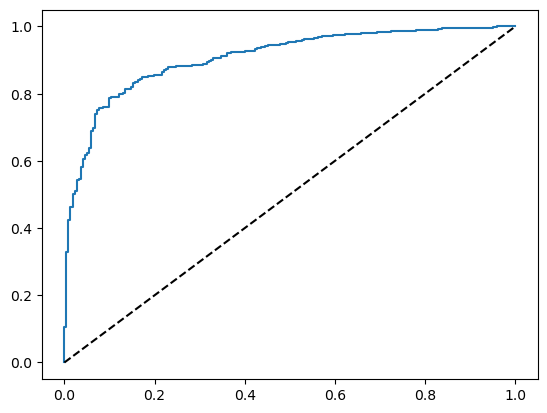

In [622]:
y_scores = model_svm.decision_function(X_test_stacked)

fpr, tpr, thresholds = metrics.roc_curve(y_test_encoded, y_scores)


roc_auc = metrics.auc(fpr, tpr)
print("AUC:", roc_auc)

j = tpr - fpr

optimal_thres = thresholds[np.argmax(j)]


plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--') # Random guess line
plt.show()

In [612]:
model_svm = joblib.load('./data/model_svm_wo_lbp_and_colors_4.pkl')

In [613]:
model_svm.fit(X_train_stacked, y_train_encoded)

,C,100
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
# joblib.dump(model_svm, './data/model_svm_08_sampling_strgy.pkl')
# joblib.dump(scaler_classic, './data/scaler_classic.pkl')
# joblib.dump(scaler_cnn, './data/scaler_cnn.pkl')
# joblib.dump(pca, './data/pca.pkl')
# joblib.dump(label_encoder, './data/label_encoder.pkl')

['./data/label_encoder.pkl']